<a href="https://colab.research.google.com/github/amypongpong/Jurkat-Cell-Cycle-Classification/blob/main/Nayoung_Kim_Research_paper_30seeds_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Quality & Annotation Error Effects on CNN Cell-Cycle Classification
### BBBC048 — Jurkat Cell Cycle Dataset

This notebook implements a controlled study of how image degradation and annotation error affect
a CNN trained to classify Jurkat cell-cycle phase:

> **Design.** A single CNN architecture is trained under four data conditions, each repeated across
> multiple random seeds:
> 1. **Clean images, correct labels** (baseline)
> 2. **Degraded images, correct labels** (isolates image-quality effect)
> 3. **Clean images, noisy labels** (isolates annotation-error effect)
> 4. **Degraded images, noisy labels** (combined effect)
>
> All four conditions are evaluated on the **same held-out, clean, correctly-labeled test set**,
> built once and shared across every condition and seed. Reporting mean ± standard deviation across
> seeds, rather than a single run, lets us say whether an observed difference is a real effect or
> noise.

**Results reported in the paper.** Every number, table and figure in the paper comes from the outputs printed in Sections 12 to 16 of this executed notebook: 4 conditions × 30 seeds = 120 runs, all on one GPU type, recorded in Section 0b. Code and outputs are shown exactly as run.

**How to use this notebook**
1. Run cells top to bottom in Google Colab (`Runtime > Run all` works, but the first time through you
   should run the *Inspect downloaded data* cells one at a time — BBBC048's internal file layout can
   vary and you may need to tweak the parsing cell marked ⚠️.)
2. `Runtime > Change runtime type > GPU (L4)`. Use the same GPU type for every session; Section 0b
   stops the notebook if it changes.
3. **Compute note**: this notebook trains 4 conditions × `len(CONFIG["seeds"])` seeds = 120 models.
   Section 12 prints the time per run and a projected total after the first run. Every finished run
   is saved to Google Drive (Section 0b), so after a disconnect, `Run all` again and training resumes
   where it stopped. To sanity-check the pipeline first, use a separate copy of this notebook with
   `CONFIG["seeds"] = [42]`, so test runs never land in the results folder.

**Citation**: Eulenberg, P., Köhler, N., Blasi, T. *et al.* "Reconstructing cell cycle and disease
progression using deep learning." *Nat Commun* 8, 463 (2017). Dataset: BBBC048, Broad Bioimage
Benchmark Collection (Ljosa et al., *Nature Methods*, 2012), CC BY-NC-SA 3.0, courtesy of Andrew Filby,
Newcastle University.


## 0. Setup

In [3]:
# Core imports
!pip install -q tifffile

import os, io, glob, zipfile, random, json, math, re, tarfile, time, shutil, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 0b. Save progress to Google Drive and record the GPU

Every finished training run is written to `MyDrive/jurkat_runs`, so a Colab disconnect costs at most
the run in progress. The first session also records the GPU model and TensorFlow version in
`run_info.json`. Later sessions must match both, because the same seed can give slightly different
results on different GPUs or library versions, and the paper reports all runs as one setup.

In [4]:
from google.colab import drive
drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/jurkat_runs"
os.makedirs(SAVE_DIR, exist_ok=True)

gpu_query = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                           capture_output=True, text=True)
GPU_NAME = gpu_query.stdout.strip().splitlines()[0] if gpu_query.returncode == 0 and gpu_query.stdout.strip() else None
if GPU_NAME is None:
    raise RuntimeError("No GPU found. Runtime > Change runtime type > L4 GPU, then Run all again.")

info_path = os.path.join(SAVE_DIR, "run_info.json")
this_session = {"gpu": GPU_NAME, "tensorflow": tf.__version__}
if os.path.exists(info_path):
    first_session = json.load(open(info_path))
    if first_session["gpu"] != GPU_NAME:
        raise RuntimeError(
            f"Earlier runs used {first_session['gpu']}, but this session has {GPU_NAME}. "
            "Change the runtime to the same GPU type and Run all again.")
    if first_session["tensorflow"] != tf.__version__:
        raise RuntimeError(
            f"Earlier runs used TensorFlow {first_session['tensorflow']}, this session has {tf.__version__}. "
            f"Run  !pip install -q tensorflow=={first_session['tensorflow']}  then Runtime > Restart session, and Run all again.")
    print("Resuming. Same GPU and TensorFlow version as the first session:", this_session)
else:
    json.dump(this_session, open(info_path, "w"))
    print("First session. Recorded:", this_session)

done = [f for f in os.listdir(SAVE_DIR) if f.endswith(".json") and f != "run_info.json"]
print(f"Runs already saved in {SAVE_DIR}: {len(done)}")

Mounted at /content/drive
Resuming. Same GPU and TensorFlow version as the first session: {'gpu': 'NVIDIA L4', 'tensorflow': '2.21.0'}
Runs already saved in /content/drive/MyDrive/jurkat_runs: 120


## 1. Download the BBBC048 dataset

Source: [Broad Bioimage Benchmark Collection — BBBC048](https://bbbc.broadinstitute.org/BBBC048)

- Images: `BBBC048v1.zip` (~1.5 GB, 32,266 single-cell images)
- Labels: `Ground_truth.lst` (cell phase per image: G1, S, G2, Prophase, Metaphase, Anaphase, Telophase)

> ⏱️ The zip is large — downloading + unzipping can take several minutes on Colab.


In [5]:
DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

ZIP_URL = "https://data.broadinstitute.org/bbbc/BBBC048/BBBC048v1.zip"
GT_URL  = "https://data.broadinstitute.org/bbbc/BBBC048/Ground_truth.lst"

zip_path = os.path.join(DATA_DIR, "BBBC048v1.zip")
gt_path  = os.path.join(DATA_DIR, "Ground_truth.lst")

if not os.path.exists(zip_path):
    !wget -q --show-progress -O "{zip_path}" "{ZIP_URL}"
else:
    print("Zip already downloaded.")

if not os.path.exists(gt_path):
    !wget -q -O "{gt_path}" "{GT_URL}"
else:
    print("Ground truth already downloaded.")

print("Zip size (MB):", round(os.path.getsize(zip_path) / 1e6, 1))


/content/data/BBBC0 100%[===================>]   1.50G  12.9MB/s    in 2m 29s  
Zip size (MB): 1611.4


In [6]:
IMAGES_DIR = os.path.join(DATA_DIR, "images")
os.makedirs(IMAGES_DIR, exist_ok=True)

# Only unzip once (this can take a few minutes the first time)
if not os.listdir(IMAGES_DIR):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(IMAGES_DIR)
    print("Extraction complete.")
else:
    print("Images already extracted.")

# Count extracted files
all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
print("Total extracted files:", len(all_files))
print("Example paths:")
for p in all_files[:10]:
    print(" ", p)


Extraction complete.
Total extracted files: 7
Example paths:
  /content/data/images/predictions.tar.gz
  /content/data/images/1540408813.tar.gz
  /content/data/images/CellCycle.mp4
  /content/data/images/scRNA.tar.gz
  /content/data/images/CellCycle.zip
  /content/data/images/final.tar.gz
  /content/data/images/CCS_final_evaluation_scripts.tar.gz


In [7]:
# BBBC048v1.zip's top level often contains *sub-archives* rather than raw images
# (e.g. CellCycle.zip, scRNA.tar.gz, predictions.tar.gz, evaluation scripts...).
# We only want the images, so we recursively extract nested .zip/.tar/.tar.gz files
# and then search specifically for image files among the results.
import tarfile

IMAGE_EXTS = (".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp")

def is_archive(path):
    return path.lower().endswith((".zip", ".tar.gz", ".tgz", ".tar"))

def extract_archive(path, dest):
    os.makedirs(dest, exist_ok=True)
    try:
        if path.lower().endswith(".zip"):
            with zipfile.ZipFile(path, 'r') as zf:
                zf.extractall(dest)
        elif path.lower().endswith((".tar.gz", ".tgz")):
            with tarfile.open(path, 'r:gz') as tf:
                tf.extractall(dest)
        elif path.lower().endswith(".tar"):
            with tarfile.open(path, 'r') as tf:
                tf.extractall(dest)
        return True
    except Exception as e:
        print(f"  Failed to extract {os.path.basename(path)}: {e}")
        return False

# Prioritize anything with "cellcycle" in the name (this study's actual image data);
# skip large unrelated bundles like scRNA / prediction / evaluation-script archives
# unless nothing else yields images.
top_level_archives = [p for p in all_files if is_archive(p)]
priority = [p for p in top_level_archives if "cellcycle" in os.path.basename(p).lower()]
others = [p for p in top_level_archives if p not in priority]
ordered_archives = priority + others

extracted_any_images = False
for archive_path in ordered_archives:
    dest = archive_path + "_extracted"
    print(f"Extracting {os.path.basename(archive_path)} ...")
    if extract_archive(archive_path, dest):
        found = glob.glob(os.path.join(dest, "**", "*.*"), recursive=True)
        n_images = sum(1 for p in found if p.lower().endswith(IMAGE_EXTS))
        print(f"  -> {len(found)} files, {n_images} look like images.")
        if n_images > 100:
            extracted_any_images = True
            print(f"  Found a promising image source in {os.path.basename(archive_path)} — stopping here.")
            break  # good enough — avoid extracting the other, likely-unrelated, large archives

# Refresh the master file list to include everything extracted so far (recursively,
# in case of a second layer of nested archives)
changed = True
seen_archives = set()
while changed:
    changed = False
    all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
    for p in all_files:
        if is_archive(p) and p not in seen_archives:
            dest = p + "_extracted"
            if not os.path.isdir(dest):
                extract_archive(p, dest)
                seen_archives.add(p)
                changed = True

all_files = glob.glob(os.path.join(IMAGES_DIR, "**", "*.*"), recursive=True)
image_files = [p for p in all_files if p.lower().endswith(IMAGE_EXTS)]

print(f"\nTotal files after recursive extraction: {len(all_files)}")
print(f"Image-like files found: {len(image_files)}")
print("Sample image paths:")
for p in image_files[:10]:
    print(" ", p)

if len(image_files) < 100:
    print("\n⚠️ Still very few images found. Print `[os.path.basename(p) for p in all_files][:30]` "
          "below to see what's actually there, and/or manually extract the remaining archives "
          "(1640408813.tar.gz, final.tar.gz) by adding: extract_archive(<path>, <path>+'_extracted')")


Extracting CellCycle.zip ...
  -> 129067 files, 129064 look like images.
  Found a promising image source in CellCycle.zip — stopping here.


/tmp/ipykernel_6172/1747891340.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(dest)



Total files after recursive extraction: 129616
Image-like files found: 129064
Sample image paths:
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/9899_Ch4.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/4920_Ch4.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/36676_Ch4.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/25590_Ch3.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/24585_Ch6.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/22612_Ch3.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/27702_merged.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/33001_Ch6.ome.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/15837_merged.jpg
  /content/data/images/CellCycle.zip_extracted/CellCycle/G1/16267_merged.jpg


## 2. Inspect the downloaded data ⚠️

BBBC048 images come from an ImageStream imaging flow cytometer, so each cell may be represented by
**multiple channel images** (e.g. brightfield + fluorescence channels) and the exact file naming
convention / `Ground_truth.lst` format can vary by release. **Run the two cells below first and look at
the printed output** — then adjust the parsing cell in Section 3 if needed (e.g. the separator, column
order, or how channel number is encoded in the filename).


In [8]:
# Look at raw content of Ground_truth.lst
with open(gt_path, "r", errors="replace") as f:
    gt_lines = f.readlines()

print("Number of lines in Ground_truth.lst:", len(gt_lines))
print("First 10 lines:")
for line in gt_lines[:10]:
    print(repr(line))


Number of lines in Ground_truth.lst: 96798
First 10 lines:
'19\t0\t./Anaphase/12432_Ch3.ome.jpg\n'
'8\t0\t./Anaphase/12432_Ch4.ome.jpg\n'
'35\t0\t./Anaphase/12432_Ch6.ome.jpg\n'
'36\t0\t./Anaphase/22004_Ch3.ome.jpg\n'
'1\t0\t./Anaphase/22004_Ch4.ome.jpg\n'
'42\t0\t./Anaphase/22004_Ch6.ome.jpg\n'
'23\t0\t./Anaphase/26511_Ch3.ome.jpg\n'
'44\t0\t./Anaphase/26511_Ch4.ome.jpg\n'
'32\t0\t./Anaphase/26511_Ch6.ome.jpg\n'
'34\t0\t./Anaphase/29554_Ch3.ome.jpg\n'


In [9]:
# Look at file extensions / naming patterns actually present among the IMAGE files
# (image_files was built in Section 1 after recursively unpacking nested archives)
exts = pd.Series([os.path.splitext(p)[1].lower() for p in image_files]).value_counts()
print("Image file extensions found:\n", exts)

# Show a handful of filenames to infer the naming convention
basenames = [os.path.basename(p) for p in image_files]
print("\nSample image filenames:")
for b in basenames[:20]:
    print(" ", b)
print(f"\nTotal image files available for matching: {len(image_files)}")


Image file extensions found:
 .jpg    129064
Name: count, dtype: int64

Sample image filenames:
  9899_Ch4.ome.jpg
  4920_Ch4.ome.jpg
  36676_Ch4.ome.jpg
  25590_Ch3.ome.jpg
  24585_Ch6.ome.jpg
  22612_Ch3.ome.jpg
  27702_merged.jpg
  33001_Ch6.ome.jpg
  15837_merged.jpg
  16267_merged.jpg
  39115_merged.jpg
  43450_Ch4.ome.jpg
  9773_Ch3.ome.jpg
  38374_merged.jpg
  15706_Ch3.ome.jpg
  17615_merged.jpg
  16876_Ch6.ome.jpg
  24570_Ch3.ome.jpg
  36_Ch3.ome.jpg
  10678_Ch6.ome.jpg

Total image files available for matching: 129064


## 3. Parse labels and match to image files ⚠️

The cell below tries a few common delimiters automatically. **If the printed class distribution at the
end looks wrong (e.g. only 1 class, or counts don't resemble ~32k total), open `Ground_truth.lst` in
the file browser on the left and adjust `SEP` / `FNAME_COL` / `LABEL_COL` below manually.**


In [10]:
CLASS_NAMES = ["G1", "S", "G2", "Prophase", "Metaphase", "Anaphase", "Telophase"]

def try_parse_ground_truth(path):
    for sep in ["\t", ",", None]:  # None = any whitespace
        try:
            df = pd.read_csv(path, sep=sep, engine="python", header=None)
            if df.shape[1] >= 2:
                return df, sep
        except Exception:
            continue
    raise ValueError("Could not auto-parse Ground_truth.lst — inspect it manually and adjust this cell.")

gt_df, used_sep = try_parse_ground_truth(gt_path)
print("Parsed with separator:", repr(used_sep))
print(gt_df.head())

# Column layout: col 0 = arbitrary per-row index, col 1 = a per-row code that is NOT a
# reliable global class label, col 2 = filepath whose *folder name* is the real,
# unambiguous class label (e.g. "./Anaphase/12432_Ch3.ome.jpg" -> "Anaphase").
# FIX: use the filepath column (not column 0) and pull the label straight from its
# folder name instead of fuzzy-matching the whole path. Fuzzy substring matching on a
# short name like "S" was matching inside "Anaphase"/"Metaphase"/"Prophase"/"Telophase"
# (which all contain the letter "s"), silently collapsing 4 of 7 classes into "S".
PATH_COL = gt_df.shape[1] - 1  # filepath column

gt_df = gt_df.rename(columns={PATH_COL: "filepath_raw"})
gt_df["filepath_raw"] = gt_df["filepath_raw"].astype(str).str.strip()

# file_key = basename of the path -> matches actual image filenames directly
gt_df["file_key"] = gt_df["filepath_raw"].apply(lambda p: os.path.basename(p))

# label_raw = folder name in the path (the true class name, exact, no fuzzy matching)
gt_df["label_raw"] = gt_df["filepath_raw"].apply(lambda p: p.strip("./").split("/")[0])

print("\nUnique raw label values found:")
print(gt_df["label_raw"].value_counts())


Parsed with separator: '\t'
    0  1                             2
0  19  0  ./Anaphase/12432_Ch3.ome.jpg
1   8  0  ./Anaphase/12432_Ch4.ome.jpg
2  35  0  ./Anaphase/12432_Ch6.ome.jpg
3  36  0  ./Anaphase/22004_Ch3.ome.jpg
4   1  0  ./Anaphase/22004_Ch4.ome.jpg

Unique raw label values found:
label_raw
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64


In [11]:
# label_raw values are now exact folder names pulled straight from the path, so they
# already match CLASS_NAMES (case aside). Map through a small case-insensitive dict for
# safety, but no more substring fuzzy-matching — that's what caused the "S" bug.
code_to_name = {c.lower(): c for c in CLASS_NAMES}
gt_df["label"] = gt_df["label_raw"].str.lower().map(code_to_name)

print(gt_df["label"].value_counts())
print("\nUnmapped labels (fix `code_to_name` above if this is non-empty):",
      sorted(set(gt_df["label"].dropna().unique()) - set(CLASS_NAMES)))


label
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64

Unmapped labels (fix `code_to_name` above if this is non-empty): []


In [12]:
# --- Matching strategy (fast version) ---
path_lookup = {}
for p in image_files:
    base = os.path.basename(p)
    stem = os.path.splitext(base)[0]
    path_lookup.setdefault(stem, []).append(p)
    path_lookup.setdefault(base, []).append(p)

gt_df["filepath"] = gt_df["file_key"].map(lambda k: path_lookup.get(k, [None])[0])
n_exact = gt_df["filepath"].notna().sum()
print(f"Exact matching: {n_exact} / {len(gt_df)} matched.")

# --- Fallback: numeric-ID matching (also O(n), no nested scanning) ---
if n_exact < 0.5 * len(gt_df):
    print("Exact matching found too few matches — falling back to numeric-ID matching.")

    def extract_id(s):
        m = re.search(r'\d+', str(s))
        return str(int(m.group())) if m else None

    id_to_paths = {}
    for p in image_files:
        fid = extract_id(os.path.basename(p))
        if fid is not None:
            id_to_paths.setdefault(fid, []).append(p)

    gt_df["file_id"] = gt_df["file_key"].apply(extract_id)
    gt_df["filepath"] = gt_df["file_id"].map(lambda fid: id_to_paths.get(fid, [None])[0])

    n_id = gt_df["filepath"].notna().sum()
    print(f"Numeric-ID matching: {n_id} / {len(gt_df)} matched.")

matched = gt_df.dropna(subset=["filepath"])
print(f"\nFinal matched: {len(matched)} / {len(gt_df)} ground-truth entries.")
print(matched["label"].value_counts())

dataset_df = matched[matched["label"].isin(CLASS_NAMES)].reset_index(drop=True)
print("\nFinal usable dataset size:", len(dataset_df))

Exact matching: 96798 / 96798 matched.

Final matched: 96798 / 96798 ground-truth entries.
label
G1           42999
S            25848
G2           25803
Prophase      1818
Metaphase      204
Telophase       81
Anaphase        45
Name: count, dtype: int64

Final usable dataset size: 96798


In [13]:
# --- DIAGNOSTICS (only needed if the match count above looks wrong) ---
print("gt_df sample:")
print(gt_df.head(10).to_string())
print()
print("Sample file_key values:", gt_df["file_key"].head(10).tolist())
print()
print("Sample actual filenames on disk:", [os.path.basename(p) for p in image_files[:10]])


gt_df sample:
    0  1                  filepath_raw           file_key label_raw     label                                                                           filepath
0  19  0  ./Anaphase/12432_Ch3.ome.jpg  12432_Ch3.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/12432_Ch3.ome.jpg
1   8  0  ./Anaphase/12432_Ch4.ome.jpg  12432_Ch4.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/12432_Ch4.ome.jpg
2  35  0  ./Anaphase/12432_Ch6.ome.jpg  12432_Ch6.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/12432_Ch6.ome.jpg
3  36  0  ./Anaphase/22004_Ch3.ome.jpg  22004_Ch3.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/22004_Ch3.ome.jpg
4   1  0  ./Anaphase/22004_Ch4.ome.jpg  22004_Ch4.ome.jpg  Anaphase  Anaphase  /content/data/images/CellCycle.zip_extracted/CellCycle/Anaphase/22004_Ch4.ome.jpg
5  42  0  ./Anaphase

## 4. Deduplicate to one image per cell ⚠️

BBBC048 captures each physical cell across multiple imaging channels (this release has three:
`Ch3`, `Ch4`, `Ch6`), and `Ground_truth.lst` repeats the same label once per channel image — so the
96,798 matched rows from Section 3 correspond to only 32,266 *unique* cells (96,798 / 3), matching
the dataset's documented size.

Training on every channel row as if it were an independent example is a problem for two reasons:
1. **Data leakage.** If the train/test split is done on channel rows rather than cells, different
   channel images of the *same* cell can land on both sides of the split — the model could partly
   learn to recognize a specific cell rather than the phase itself, inflating test performance.
2. **Undifferentiated channels.** Without documentation mapping `Ch3`/`Ch4`/`Ch6` to a specific
   imaging modality (brightfield, darkfield, or a fluorescence stain) in this pipeline, blending all
   three together as if they were equivalent grayscale images mixes channels that may carry very
   different amounts of cell-cycle signal.

We address both by keeping exactly **one, consistently-chosen** image per physical cell. The cell
identifier is extracted from the filename, and for every cell we deterministically keep its lowest
channel number (e.g. `Ch3` over `Ch4`/`Ch6` when available), so every retained image comes from the
same channel type wherever possible.


In [14]:
def extract_cell_id(filename):
    """Pull the numeric cell ID that prefixes every BBBC048 filename, e.g. '12432' from
    '12432_Ch3.ome.jpg'."""
    m = re.search(r'(\d+)_', os.path.basename(filename))
    return m.group(1) if m else None

def extract_channel(filename):
    """Pull the channel/variant token, e.g. 'Ch3', 'Ch4', 'Ch6', or 'merged'."""
    m = re.search(r'_(Ch\d+|merged)\.', os.path.basename(filename))
    return m.group(1) if m else "zzz_unknown"

dataset_df["cell_id"] = dataset_df["filepath"].apply(extract_cell_id)
dataset_df["channel"] = dataset_df["filepath"].apply(extract_channel)

n_before = len(dataset_df)

# Deterministic tie-break: sort by channel name (Ch3 < Ch4 < Ch6 alphabetically) so the
# same channel is preferred for every cell where it's available, then keep one row/cell.
dataset_df = dataset_df.sort_values(["cell_id", "channel"])
dataset_df = dataset_df.drop_duplicates(subset="cell_id", keep="first").reset_index(drop=True)

print(f"Deduplicated {n_before} channel-image rows -> {len(dataset_df)} unique cells "
      f"({n_before / max(len(dataset_df), 1):.2f}x reduction, expected ~3x).")
print("\nClass counts after deduplication:")
print(dataset_df["label"].value_counts())
print("\nChannel actually used per cell (should be dominated by a single value):")
print(dataset_df["channel"].value_counts())


Deduplicated 96798 channel-image rows -> 32266 unique cells (3.00x reduction, expected ~3x).

Class counts after deduplication:
label
G1           14333
S             8616
G2            8601
Prophase       606
Metaphase       68
Telophase       27
Anaphase        15
Name: count, dtype: int64

Channel actually used per cell (should be dominated by a single value):
channel
Ch3    32266
Name: count, dtype: int64


## 5. Configuration

Two design choices:
- Instead of forcing every class to contribute an equal (and therefore tiny) number of images, we
  keep **up to `max_train_per_class`** images per class — all of a rare class's images if it has
  fewer than the cap, and a random sample of the cap otherwise — and let **class-weighted training**
  (Section 10) handle the remaining imbalance. This uses far more of the available data for the
  common interphase classes than a forced-equal split would.
- `CONDITIONS` defines the 2×2 design (image quality × label quality), and `CONFIG["seeds"]` controls
  how many independent repeats each condition gets. The 30 seeds are fixed before any
  results are seen and every run is reported, so no seed can be dropped or added after the fact.
  They are the three seeds from the pilot run (42, 7, 123) plus 1 to 28, with 7 not repeated.


In [15]:
CONFIG = {
    "img_size": 64,              # images resized to img_size x img_size
    "test_frac": 0.10,           # fraction of each class reserved for the shared test set
    "min_test_per_class": 5,     # floor on test examples per class, availability permitting
    "max_train_per_class": 2000, # cap per class in the training pool; classes smaller than this
                                  # keep everything they have (no artificial equal-sizing)
    "batch_size": 32,
    "epochs": 20,
    "label_noise_rate": 0.25,    # fraction of labels randomly corrupted in "noisy label" conditions
    "blur_radius": 2.0,          # Gaussian blur radius for degraded-image conditions
    "noise_std": 25,             # std-dev of additive Gaussian pixel noise (0-255 scale)
    "jpeg_quality": 15,          # low JPEG quality -> compression artifacts
    "seeds": [42, 7, 123, 1, 2, 3, 4, 5, 6] + list(range(8, 29)),  # 30 seeds, fixed in advance
    "augment": True,             # random horizontal/vertical flip on training images only

    # --- Training stability ---
    "grad_clip_norm": 1.0,       # clip gradients to this global norm (Adam(clipnorm=...))
    "label_smoothing": 0.05,     # softens one-hot targets; reduces the loss's incentive to fit
                                  # a mislabeled example with full confidence
    "max_class_weight": 10.0,    # cap on inverse-frequency class weights, so a handful of
                                  # mislabeled rare-class examples can't dominate the gradient
    "lr_factor": 0.5,            # ReduceLROnPlateau: multiply LR by this on plateau
    "lr_patience": 2,            # epochs with no val_loss improvement before reducing LR
    "min_lr": 1e-6,
}

CONDITIONS = [
    {"key": "clean_correct",    "name": "Clean images, correct labels (baseline)",        "degrade": False, "noisy_labels": False},
    {"key": "degraded_correct", "name": "Degraded images, correct labels",                "degrade": True,  "noisy_labels": False},
    {"key": "clean_noisy",      "name": "Clean images, noisy labels",                     "degrade": False, "noisy_labels": True},
    {"key": "degraded_noisy",   "name": "Degraded images, noisy labels (combined)",       "degrade": True,  "noisy_labels": True},
]

# Safety: never proceed with an unreasonably small matched dataset.
n_avail = len(dataset_df)
if n_avail < 50:
    raise ValueError(
        f"Only {n_avail} unique cells matched labels to files — that's too few to train on. "
        "Scroll up, run the DIAGNOSTICS cell in Section 3, and check whether "
        "'Sample file_key values' actually look like the IDs in 'Sample actual filenames'. "
        "Fix the matching there before continuing."
    )

print(f"{n_avail} unique cells available after deduplication.")
print("Class counts:")
print(dataset_df["label"].value_counts())
assert len(set(CONFIG["seeds"])) == len(CONFIG["seeds"]) == 30, "seed list must be 30 unique seeds"
print(f"\nPlanned runs: {len(CONDITIONS)} conditions x {len(CONFIG['seeds'])} seeds "
      f"= {len(CONDITIONS) * len(CONFIG['seeds'])} total training runs.")


32266 unique cells available after deduplication.
Class counts:
label
G1           14333
S             8616
G2            8601
Prophase       606
Metaphase       68
Telophase       27
Anaphase        15
Name: count, dtype: int64

Planned runs: 4 conditions x 30 seeds = 120 total training runs.


## 6. Train / test split (cell-level, class-proportional, shared across every condition)

The split is performed **once**, on the deduplicated cell-level data, so:
- no physical cell can appear in both the training pool and the test set (fixes the leakage risk
  described in Section 4), and
- the exact same clean, correctly-labeled test set is used to evaluate every condition and every
  seed, so comparisons across conditions are apples-to-apples.

Rather than forcing every class down to the rarest class's size, each class contributes a
proportional share (`test_frac`) to the test set, with a minimum floor (`min_test_per_class`) so
even the rarest mitotic phases get a handful of test examples instead of zero or one.


In [16]:
def split_train_test(df, class_col, test_frac, min_test_per_class, seed):
    """Class-proportional split with a floor per class, so rare classes still get some test
    examples instead of being crowded out or left with none."""
    train_parts, test_parts = [], []
    for c, grp in df.groupby(class_col):
        n = len(grp)
        if n < 2:
            train_parts.append(grp)  # too few to hold any out for testing
            continue
        n_test = max(min_test_per_class, int(round(n * test_frac)))
        n_test = min(n_test, n - 1)  # always leave at least 1 example for training
        grp = grp.sample(frac=1, random_state=seed)
        test_parts.append(grp.iloc[:n_test])
        train_parts.append(grp.iloc[n_test:])
    train_df = pd.concat(train_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    test_df = (pd.concat(test_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
               if test_parts else df.iloc[0:0].copy())
    return train_df, test_df

def cap_per_class(df, class_col, cap, seed):
    """Keep up to `cap` images per class; classes smaller than the cap keep everything."""
    parts = []
    for c, grp in df.groupby(class_col):
        parts.append(grp.sample(n=cap, random_state=seed) if len(grp) > cap else grp)
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

train_pool_df, test_df = split_train_test(
    dataset_df, "label", CONFIG["test_frac"], CONFIG["min_test_per_class"], seed=SEED
)
train_pool_df = cap_per_class(train_pool_df, "label", CONFIG["max_train_per_class"], seed=SEED)

print("Training pool:", len(train_pool_df), "cells")
print(train_pool_df["label"].value_counts())
print("\nShared test set:", len(test_df), "cells (fixed for every condition and every seed)")
print(test_df["label"].value_counts())

overlap = set(train_pool_df["cell_id"]) & set(test_df["cell_id"])
print(f"\nCell-ID overlap between train and test: {len(overlap)} (should be 0)")


Training pool: 6638 cells
label
G1           2000
S            2000
G2           2000
Prophase      545
Metaphase      61
Telophase      22
Anaphase       10
Name: count, dtype: int64

Shared test set: 3233 cells (fixed for every condition and every seed)
label
G1           1433
S             862
G2            860
Prophase       61
Metaphase       7
Anaphase        5
Telophase       5
Name: count, dtype: int64

Cell-ID overlap between train and test: 0 (should be 0)


## 7. Image loading utilities

`augment_image` applies a random horizontal and/or vertical flip. This is a defensible augmentation
here specifically because these are single suspended cells imaged by flow cytometry — they have no
canonical orientation, so flipping does not change their true label. Augmentation is applied only to
training images, never to the shared test set.


In [17]:
def load_image(path, size):
    try:
        img = Image.open(path)
        if img.mode not in ("L",):
            img = img.convert("L")  # grayscale
    except Exception:
        # Fallback for TIFF variants PIL struggles with (e.g. some ImageStream exports)
        import tifffile
        arr_raw = tifffile.imread(path)
        if arr_raw.ndim == 3:
            arr_raw = arr_raw[..., 0]
        arr_raw = ((arr_raw - arr_raw.min()) / (np.ptp(arr_raw) + 1e-8) * 255).astype(np.uint8)
        img = Image.fromarray(arr_raw)
    img = img.resize((size, size))
    return np.array(img, dtype=np.uint8)

def augment_image(arr, rng):
    if rng.random() < 0.5:
        arr = np.fliplr(arr)
    if rng.random() < 0.5:
        arr = np.flipud(arr)
    return arr

def images_to_array(df, size, degrade_fn=None, augment=False, seed=SEED):
    rng = random.Random(seed)
    imgs = []
    for p in df["filepath"]:
        arr = load_image(p, size)
        if degrade_fn is not None:
            arr = degrade_fn(arr)
        if augment:
            arr = augment_image(arr, rng)
        imgs.append(arr)
    X = np.stack(imgs).astype("float32") / 255.0
    X = np.expand_dims(X, -1)  # add channel dim -> (N, H, W, 1)
    return X


## 8. Degradation and label-noise utilities

`degrade_image` combines Gaussian blur, JPEG re-compression, and additive Gaussian noise to simulate
poor acquisition/focus/compression. `inject_label_noise` randomly reassigns a fraction of labels to
an incorrect class to simulate human annotation error. Both are applied independently depending on
which of the four `CONDITIONS` is being built (Section 12), so their effects can be attributed
separately as well as in combination.


In [18]:
def degrade_image(arr):
    img = Image.fromarray(arr)
    # 1. Blur
    img = img.filter(ImageFilter.GaussianBlur(radius=CONFIG["blur_radius"]))
    # 2. JPEG compression artifacts
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=CONFIG["jpeg_quality"])
    buf.seek(0)
    img = Image.open(buf).convert("L")
    arr2 = np.array(img, dtype=np.float32)
    # 3. Additive Gaussian noise
    noise = np.random.normal(0, CONFIG["noise_std"], arr2.shape)
    arr2 = np.clip(arr2 + noise, 0, 255).astype(np.uint8)
    return arr2

def inject_label_noise(labels, class_names, noise_rate, seed=SEED):
    rng = np.random.RandomState(seed)
    labels = list(labels)
    n_flip = int(len(labels) * noise_rate)
    flip_idx = rng.choice(len(labels), size=n_flip, replace=False)
    noisy_labels = labels.copy()
    for i in flip_idx:
        wrong_choices = [c for c in class_names if c != labels[i]]
        noisy_labels[i] = rng.choice(wrong_choices)
    return noisy_labels, set(flip_idx)


## 9. Build the shared clean test set

Original images, correct labels, no augmentation — built once, and never touched again. Every
condition in Section 12 is evaluated against this exact same set.


In [19]:
label_encoder = LabelEncoder().fit(CLASS_NAMES)
NUM_CLASSES = len(CLASS_NAMES)
INPUT_SHAPE = (CONFIG["img_size"], CONFIG["img_size"], 1)

X_test = images_to_array(test_df, CONFIG["img_size"], augment=False)
y_test_idx = label_encoder.transform(test_df["label"])
y_test = tf.keras.utils.to_categorical(y_test_idx, NUM_CLASSES)

print("X_test:", X_test.shape, " y_test:", y_test.shape)


X_test: (3233, 64, 64, 1)  y_test: (3233, 7)


## 10. CNN architecture

Every run uses the identical architecture and hyperparameters, reseeded before construction so
initial weights are identical across runs that share a seed — the only things that vary across runs
are the training data (per condition) and the seed (per repeat).

Stability measures added to guard against the model collapsing or diverging under noisy/degraded
training data:
- **He (Kaiming) initialization** on every ReLU layer, a better match for ReLU's activation
  variance than the default Glorot initializer.
- **Gradient clipping** (`clipnorm`) on the optimizer, capping the global gradient norm each step.
- **Label smoothing**, which softens one-hot targets so the loss never demands 100% confidence on
  any single example — this directly limits how much a mislabeled example (under the noisy-label
  conditions) can pull the model's decision boundary.
- **Capped class weights** (`get_class_weights(..., max_weight=...)`), so a handful of mislabeled
  examples landing in a very rare class can't be weighted as if they were dozens of ordinary
  examples.

`get_class_weights` computes inverse-frequency class weights so the model is penalized more for
misclassifying rare classes, instead of relying on artificially shrinking the common classes down to
match the rarest one.


In [20]:
from sklearn.utils.class_weight import compute_class_weight

def build_cnn(input_shape, num_classes, seed=SEED,
              grad_clip_norm=None, label_smoothing=0.0, learning_rate=1e-3):
    tf.random.set_seed(seed)  # keep initial weights identical across runs sharing a seed

    # He/Kaiming initialization: the recommended pairing for ReLU activations (Glorot's default
    # assumes a different activation variance profile and is a slightly worse fit here).
    init = tf.keras.initializers.HeNormal(seed=seed)

    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu", padding="same", kernel_initializer=init),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_initializer=init),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax", kernel_initializer="glorot_uniform"),
    ])

    # Gradient clipping (global norm): the Keras equivalent of
    # torch.nn.utils.clip_grad_norm_ — pass clipnorm directly to the optimizer rather than
    # clipping manually, since Keras applies it inside the optimizer's apply_gradients step.
    optimizer_kwargs = {"learning_rate": learning_rate}
    if grad_clip_norm is not None:
        optimizer_kwargs["clipnorm"] = grad_clip_norm

    # Label smoothing softens one-hot targets (e.g. 1.0 -> 0.95, 0.0 -> ~0.008 per remaining
    # class) so the loss never asks the model to be 100% confident about any single example.
    # This directly reduces how much a mislabeled example can pull the decision boundary,
    # without needing to know which examples are mislabeled.
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(**optimizer_kwargs),
        loss=loss,
        metrics=["accuracy"],
    )
    return model

def get_class_weights(y_idx, num_classes, max_weight=None):
    """Inverse-frequency class weights, optionally capped so a handful of mislabeled
    rare-class examples (under label noise) cannot dominate the gradient update. Without a
    cap, a class representing e.g. 0.1% of the data can receive a weight in the hundreds;
    combined with label noise, a single mislabeled example assigned to that class would then
    be weighted as if it were hundreds of ordinary examples."""
    present = np.unique(y_idx)
    weights = compute_class_weight(class_weight="balanced", classes=present, y=y_idx)
    if max_weight is not None:
        weights = np.minimum(weights, max_weight)
    cw = {int(c): float(w) for c, w in zip(present, weights)}
    for c in range(num_classes):
        cw.setdefault(c, 1.0)
    return cw

build_cnn(INPUT_SHAPE, NUM_CLASSES,
          grad_clip_norm=CONFIG["grad_clip_norm"],
          label_smoothing=CONFIG["label_smoothing"]).summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,175 (4.36 MB)

 Trainable params: 1,142,727 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 11. Evaluation helper

Defined once, used for every run. Display names come from `label_encoder.classes_` (not a
hand-written class list) so per-class names in every report are guaranteed to match the encoder's
actual index assignment.


In [21]:
def evaluate_model(model, X_test, y_test_idx, class_names, run_name, verbose=True):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)

    acc = accuracy_score(y_test_idx, preds)
    prec_macro = precision_score(y_test_idx, preds, average="macro", zero_division=0)
    rec_macro = recall_score(y_test_idx, preds, average="macro", zero_division=0)
    f1_macro = f1_score(y_test_idx, preds, average="macro", zero_division=0)

    if verbose:
        print(f"  {run_name}: accuracy={acc:.4f}  precision_macro={prec_macro:.4f}  "
              f"recall_macro={rec_macro:.4f}  f1_macro={f1_macro:.4f}")

    return {
        "run_name": run_name,
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "preds": preds,
    }


## 12. Multi-condition, multi-seed training

For every seed, every one of the four conditions is built fresh (its own image degradation and/or
label-noise draw, controlled by that seed) and trained from a freshly (re-)initialized model using
that same seed. `set_all_seeds()` reseeds Python, NumPy, and TensorFlow (and enables TF's
deterministic-ops mode where available) at the start of every single run, not just once per outer
loop, so results are reproducible run-to-run. Every run is evaluated on the one shared test set built
in Section 9.

Two additional safeguards run inside every `model.fit` call: `EarlyStopping` (as before) and
`ReduceLROnPlateau`, which halves the learning rate if validation loss stops improving.

This is the most expensive cell in the notebook. Each finished run is saved to Google Drive
(Section 0b) and skipped if this cell is run again, so after a disconnect, `Run all` resumes where it
stopped. The cell prints how long each run took and a projected time for the runs still to do.
Models are kept only for the first seed (used in Section 15); for the other runs, only the metrics,
predictions and training curves are kept, which keeps memory use flat across 120 runs.


In [22]:
def set_all_seeds(seed):
    """True cross-library determinism: Python's random module, NumPy, TensorFlow, hash seeding,
    and (where available) TF's deterministic-ops mode. Called once at the start of every run so
    a given seed reproduces the same weight init, batch order, augmentation draws, degradation
    noise, and label-noise flips every time this cell is re-executed."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        # Available on TF >= 2.8; makes GPU ops deterministic too (some throughput cost).
        tf.config.experimental.enable_op_determinism()
    except AttributeError:
        pass

def build_condition_dataset(train_pool_df, condition, seed, class_names, label_encoder):
    # np.random.seed(seed) below covers degrade_image()'s additive-noise draw, which reads
    # from the global NumPy RNG rather than a local RandomState.
    degrade_fn = degrade_image if condition["degrade"] else None
    X = images_to_array(train_pool_df, CONFIG["img_size"], degrade_fn=degrade_fn,
                         augment=CONFIG["augment"], seed=seed)

    labels = train_pool_df["label"].tolist()
    if condition["noisy_labels"]:
        labels, flipped_idx = inject_label_noise(labels, class_names, CONFIG["label_noise_rate"], seed=seed)
    else:
        flipped_idx = set()

    y_idx = label_encoder.transform(labels)
    y_cat = tf.keras.utils.to_categorical(y_idx, len(class_names))
    return X, y_idx, y_cat, flipped_idx

all_run_results = []
histories = {}          # run_id -> dict of per-epoch metrics (loss, val_accuracy, ...)
models_store = {}       # first-seed models only
first_seed = CONFIG["seeds"][0]
total_runs = len(CONFIG["seeds"]) * len(CONDITIONS)
session_times = []

def to_jsonable(d):
    return {k: ([float(x) for x in v] if isinstance(v, list) else v) for k, v in d.items()}

for seed in CONFIG["seeds"]:
    print(f"\n{'='*70}\nSEED {seed}\n{'='*70}")
    for condition in CONDITIONS:
        run_id = f"{condition['key']}__seed{seed}"
        done_file = os.path.join(SAVE_DIR, f"{run_id}.json")
        model_file = os.path.join(SAVE_DIR, f"model_{run_id}.keras")
        if os.path.exists(done_file):
            r = json.load(open(done_file))
            r["preds"] = np.load(os.path.join(SAVE_DIR, f"{run_id}_preds.npy"))
            histories[run_id] = r.pop("history")
            all_run_results.append(r)
            if seed == first_seed and os.path.exists(model_file):
                models_store[run_id] = tf.keras.models.load_model(model_file)
            print(f"  loaded saved run: {run_id}  accuracy={r['accuracy']:.4f}")
            continue

        tf.keras.backend.clear_session()  # free the previous run's model before building the next
        t0 = time.time()
        set_all_seeds(seed)  # reseed before every run, not just once per outer loop

        X_train, y_train_idx, y_train_cat, flipped_idx = build_condition_dataset(
            train_pool_df, condition, seed, CLASS_NAMES, label_encoder
        )
        class_weights = get_class_weights(y_train_idx, NUM_CLASSES,
                                           max_weight=CONFIG["max_class_weight"])

        model = build_cnn(INPUT_SHAPE, NUM_CLASSES, seed=seed,
                           grad_clip_norm=CONFIG["grad_clip_norm"],
                           label_smoothing=CONFIG["label_smoothing"])

        early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=CONFIG["lr_factor"], patience=CONFIG["lr_patience"],
            min_lr=CONFIG["min_lr"], verbose=0,
        )

        history = model.fit(
            X_train, y_train_cat,
            validation_split=0.15,
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            class_weight=class_weights,
            callbacks=[early_stop, reduce_lr],
            verbose=0,
        )
        histories[run_id] = to_jsonable(history.history)
        if seed == first_seed:
            models_store[run_id] = model
            model.save(model_file)

        result = evaluate_model(model, X_test, y_test_idx, label_encoder.classes_,
                                 f"{condition['name']} (seed {seed})")
        result["condition_key"] = condition["key"]
        result["condition_name"] = condition["name"]
        result["seed"] = seed
        result["labels_corrupted"] = len(flipped_idx)
        result["max_class_weight_applied"] = float(max(class_weights.values()))
        result["epochs_trained"] = len(history.history["loss"])
        result["run_seconds"] = round(time.time() - t0, 1)
        result["gpu"] = GPU_NAME
        all_run_results.append(result)

        np.save(os.path.join(SAVE_DIR, f"{run_id}_preds.npy"), result["preds"])
        saved = {k: v for k, v in result.items() if k != "preds"}
        saved["history"] = histories[run_id]
        json.dump(saved, open(done_file, "w"))

        session_times.append(result["run_seconds"])
        remaining = total_runs - len(all_run_results)
        eta_h = remaining * np.mean(session_times) / 3600
        print(f"    run took {result['run_seconds']/60:.1f} min, {len(all_run_results)}/{total_runs} done, "
              f"about {eta_h:.1f} h left at this pace")

print(f"\nCompleted {len(all_run_results)} training runs "
      f"({len(CONDITIONS)} conditions x {len(CONFIG['seeds'])} seeds).")



SEED 42
  loaded saved run: clean_correct__seed42  accuracy=0.6913
  loaded saved run: degraded_correct__seed42  accuracy=0.5401
  loaded saved run: clean_noisy__seed42  accuracy=0.2057
  loaded saved run: degraded_noisy__seed42  accuracy=0.3829

SEED 7
  loaded saved run: clean_correct__seed7  accuracy=0.6659
  loaded saved run: degraded_correct__seed7  accuracy=0.5382
  loaded saved run: clean_noisy__seed7  accuracy=0.0022
  loaded saved run: degraded_noisy__seed7  accuracy=0.3873

SEED 123
  loaded saved run: clean_correct__seed123  accuracy=0.7207
  loaded saved run: degraded_correct__seed123  accuracy=0.2057
  loaded saved run: clean_noisy__seed123  accuracy=0.4219
  loaded saved run: degraded_noisy__seed123  accuracy=0.1624

SEED 1
  loaded saved run: clean_correct__seed1  accuracy=0.7244
  loaded saved run: degraded_correct__seed1  accuracy=0.5227
  loaded saved run: clean_noisy__seed1  accuracy=0.0019
  loaded saved run: degraded_noisy__seed1  accuracy=0.3542

SEED 2
  loaded 

## 13. Aggregate results across seeds

Reporting mean ± standard deviation across seeds (rather than a single run) is what lets the paper
say whether a difference between conditions is a real, repeatable effect or within the noise of a
single training run.


In [23]:
results_df = pd.DataFrame([
    {"condition": r["condition_name"], "seed": r["seed"], "accuracy": r["accuracy"],
     "precision_macro": r["precision_macro"], "recall_macro": r["recall_macro"],
     "f1_macro": r["f1_macro"], "labels_corrupted": r["labels_corrupted"]}
    for r in all_run_results
])

summary_df = results_df.groupby("condition")[
    ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
].agg(["mean", "std"]).reindex([c["name"] for c in CONDITIONS])

print("Per-run results:")
print(results_df.round(4).to_string(index=False))
print("\nSummary (mean \u00b1 std across seeds):")
print(summary_df.round(4))


Per-run results:
                               condition  seed  accuracy  precision_macro  recall_macro  f1_macro  labels_corrupted
 Clean images, correct labels (baseline)    42    0.6913           0.4793        0.4783    0.4534                 0
         Degraded images, correct labels    42    0.5401           0.2878        0.2942    0.2651                 0
              Clean images, noisy labels    42    0.2057           0.0697        0.0725    0.0686              1659
Degraded images, noisy labels (combined)    42    0.3829           0.0619        0.1519    0.0829              1659
 Clean images, correct labels (baseline)     7    0.6659           0.3257        0.3852    0.3193                 0
         Degraded images, correct labels     7    0.5382           0.2910        0.2139    0.2064                 0
              Clean images, noisy labels     7    0.0022           0.0003        0.1429    0.0006              1659
Degraded images, noisy labels (combined)     7    0.387

### 13a. Clean summary table (accuracy, precision, recall, F1 — one row per condition)

Compact summary table: one row per condition, each metric shown as
`mean ± std` across seeds.


In [24]:
def fmt_mean_std(mean, std):
    return f"{mean*100:.2f}% \u00b1 {std*100:.2f}%" if pd.notna(std) else f"{mean*100:.2f}%"

clean_summary = pd.DataFrame({
    "Condition": [c["name"] for c in CONDITIONS],
    "Accuracy": [fmt_mean_std(summary_df.loc[c["name"], ("accuracy", "mean")],
                               summary_df.loc[c["name"], ("accuracy", "std")]) for c in CONDITIONS],
    "Precision (macro)": [fmt_mean_std(summary_df.loc[c["name"], ("precision_macro", "mean")],
                                        summary_df.loc[c["name"], ("precision_macro", "std")]) for c in CONDITIONS],
    "Recall (macro)": [fmt_mean_std(summary_df.loc[c["name"], ("recall_macro", "mean")],
                                     summary_df.loc[c["name"], ("recall_macro", "std")]) for c in CONDITIONS],
    "F1 (macro)": [fmt_mean_std(summary_df.loc[c["name"], ("f1_macro", "mean")],
                                 summary_df.loc[c["name"], ("f1_macro", "std")]) for c in CONDITIONS],
    "Seeds": [len(CONFIG["seeds"])] * len(CONDITIONS),
})

print(clean_summary.to_string(index=False))
clean_summary.to_csv("/content/results_clean_summary.csv", index=False) if os.path.exists("/content") else None
clean_summary


                               Condition        Accuracy Precision (macro) Recall (macro)     F1 (macro)  Seeds
 Clean images, correct labels (baseline)  69.77% ± 3.03%    39.47% ± 7.57% 42.05% ± 5.43% 38.81% ± 6.46%     30
         Degraded images, correct labels 30.94% ± 16.16%    18.59% ± 9.09% 18.48% ± 5.44% 12.25% ± 7.50%     30
              Clean images, noisy labels 17.25% ± 19.35%     8.38% ± 7.27% 14.37% ± 3.61%  4.41% ± 4.68%     30
Degraded images, noisy labels (combined) 23.14% ± 16.40%    10.92% ± 5.79% 15.24% ± 3.23%  7.78% ± 4.75%     30


,Condition,Accuracy,Precision (macro),Recall (macro),F1 (macro),Seeds
0,"Clean images, correct labels (baseline)",69.77% ± 3.03%,39.47% ± 7.57%,42.05% ± 5.43%,38.81% ± 6.46%,30
1,"Degraded images, correct labels",30.94% ± 16.16%,18.59% ± 9.09%,18.48% ± 5.44%,12.25% ± 7.50%,30
2,"Clean images, noisy labels",17.25% ± 19.35%,8.38% ± 7.27%,14.37% ± 3.61%,4.41% ± 4.68%,30
3,"Degraded images, noisy labels (combined)",23.14% ± 16.40%,10.92% ± 5.79%,15.24% ± 3.23%,7.78% ± 4.75%,30


### 13b. Collapse analysis (rule fixed before the run)

A mean ± SD can hide what individual runs did. A run is counted as **collapsed** if **90% or more of
its test predictions fall in a single class**, whichever class that is. A model that labels every cell
G1 scores about 44% accuracy (G1's share of the test set) without having learned anything, so accuracy
alone cannot detect collapse. This rule was set before the 30-seed run and is applied to every run.

For each condition the table reports how many runs collapsed, a 95% Wilson confidence interval for the
collapse rate, and which classes the collapsed runs predicted.

In [25]:
COLLAPSE_SHARE = 0.90   # fixed before the run; do not change after seeing results

def dominant_prediction(preds):
    counts = np.bincount(preds, minlength=NUM_CLASSES)
    k = int(counts.argmax())
    return label_encoder.classes_[k], counts[k] / len(preds)

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return max(0.0, centre - half), min(1.0, centre + half)

dom = [dominant_prediction(r["preds"]) for r in all_run_results]
results_df["dominant_class"] = [d[0] for d in dom]
results_df["dominant_share"] = [d[1] for d in dom]
results_df["collapsed"] = results_df["dominant_share"] >= COLLAPSE_SHARE

rows = []
for c in CONDITIONS:
    sub = results_df[results_df["condition"] == c["name"]]
    k, n = int(sub["collapsed"].sum()), len(sub)
    lo, hi = wilson_ci(k, n)
    collapsed_to = sub.loc[sub["collapsed"], "dominant_class"].value_counts()
    rows.append({
        "Condition": c["name"],
        "Collapsed runs": f"{k} / {n}",
        "Collapse rate": f"{100*k/n:.0f}%",
        "95% CI (Wilson)": f"{100*lo:.0f}% to {100*hi:.0f}%",
        "Collapsed to": ", ".join(f"{cls} ({cnt})" for cls, cnt in collapsed_to.items()) or "none",
        "Accuracy, non-collapsed runs": (f"{100*sub.loc[~sub['collapsed'], 'accuracy'].mean():.2f}%"
                                          if (~sub["collapsed"]).any() else "n/a"),
    })
collapse_summary = pd.DataFrame(rows)
print(collapse_summary.to_string(index=False))

print("\nEvery run, with its most-predicted class:")
print(results_df[["condition", "seed", "accuracy", "dominant_class", "dominant_share", "collapsed"]]
      .round(4).to_string(index=False))
collapse_summary

                               Condition Collapsed runs Collapse rate 95% CI (Wilson)                                                             Collapsed to Accuracy, non-collapsed runs
 Clean images, correct labels (baseline)         0 / 30            0%       0% to 11%                                                                     none                       69.77%
         Degraded images, correct labels         6 / 30           20%      10% to 37%                             G2 (3), Telophase (1), Metaphase (1), G1 (1)                       33.47%
              Clean images, noisy labels        23 / 30           77%      59% to 88% Anaphase (7), G1 (7), Metaphase (4), Prophase (3), G2 (1), Telophase (1)                       23.97%
Degraded images, noisy labels (combined)         7 / 30           23%      12% to 41%                        G1 (3), Prophase (2), Anaphase (1), Metaphase (1)                       24.31%

Every run, with its most-predicted class:
                 

,Condition,Collapsed runs,Collapse rate,95% CI (Wilson),Collapsed to,"Accuracy, non-collapsed runs"
0,"Clean images, correct labels (baseline)",0 / 30,0%,0% to 11%,none,69.77%
1,"Degraded images, correct labels",6 / 30,20%,10% to 37%,"G2 (3), Telophase (1), Metaphase (1), G1 (1)",33.47%
2,"Clean images, noisy labels",23 / 30,77%,59% to 88%,"Anaphase (7), G1 (7), Metaphase (4), Prophase ...",23.97%
3,"Degraded images, noisy labels (combined)",7 / 30,23%,12% to 41%,"G1 (3), Prophase (2), Anaphase (1), Metaphase (1)",24.31%


## 14. Visualizations

Confusion matrices are shown for the first seed as a representative example; the bar chart below
uses the full mean ± std across all seeds.


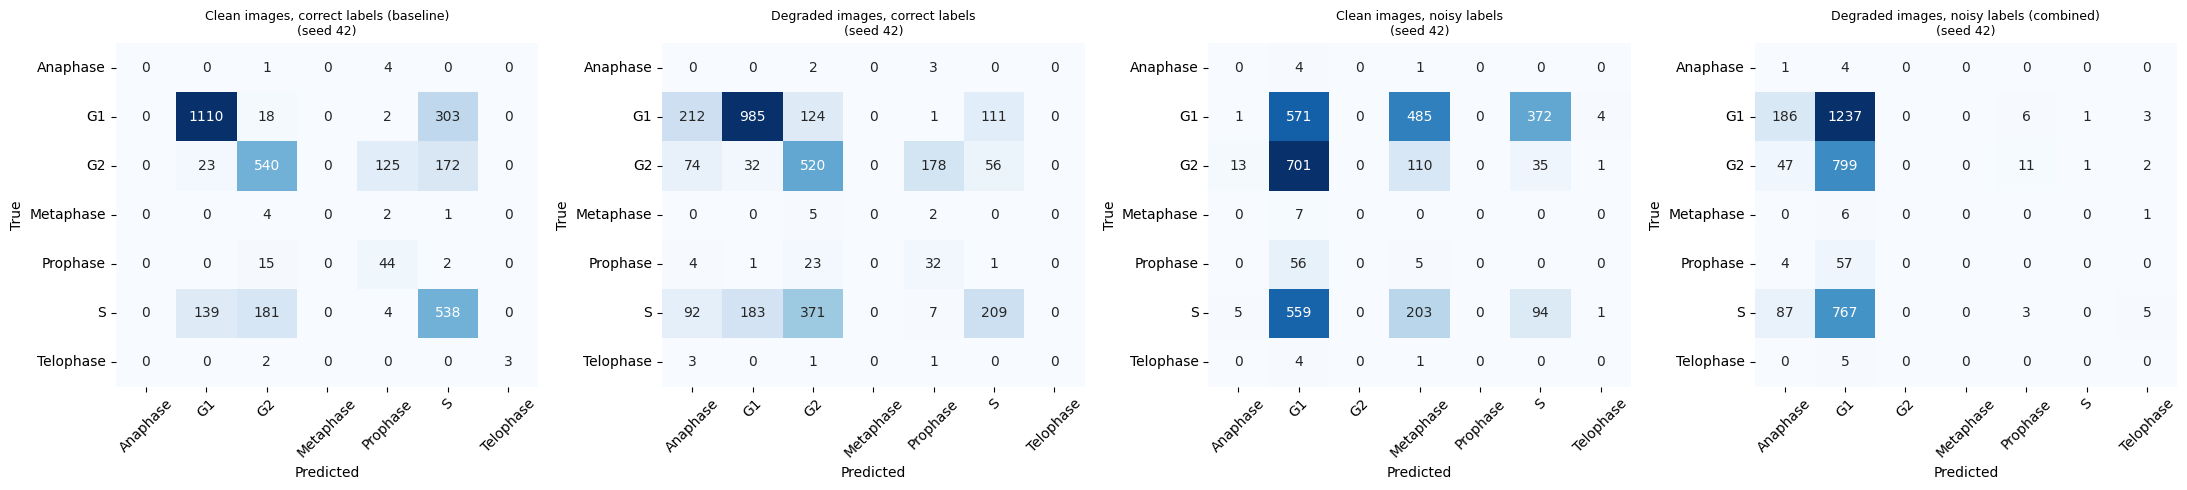

In [26]:
# Confusion matrices, one per condition, for a representative (first) seed
first_seed = CONFIG["seeds"][0]
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(5.5 * len(CONDITIONS), 5))
if len(CONDITIONS) == 1:
    axes = [axes]
for ax, condition in zip(axes, CONDITIONS):
    r = next(x for x in all_run_results if x["condition_key"] == condition["key"] and x["seed"] == first_seed)
    cm = confusion_matrix(y_test_idx, r["preds"], labels=range(NUM_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(condition["name"] + f"\n(seed {first_seed})", fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


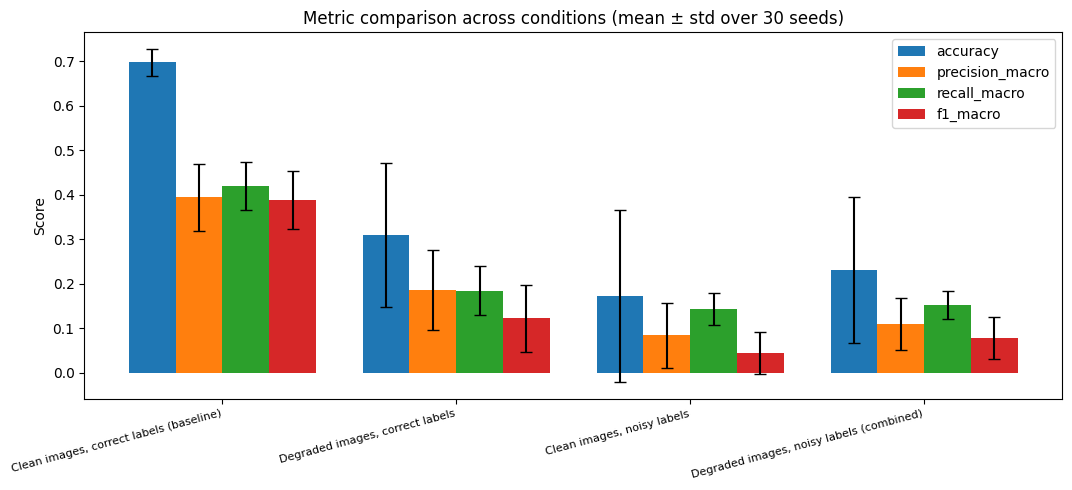

In [27]:
# Metric comparison across conditions, mean +/- std over seeds
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
condition_names = [c["name"] for c in CONDITIONS]
x = np.arange(len(condition_names))
width = 0.2

plt.figure(figsize=(11, 5))
for i, m in enumerate(metrics_to_plot):
    means = [summary_df.loc[name, (m, "mean")] for name in condition_names]
    stds = [summary_df.loc[name, (m, "std")] for name in condition_names]
    plt.bar(x + i * width, means, width, yerr=stds, capsize=4, label=m)
plt.xticks(x + width * 1.5, condition_names, rotation=15, ha="right", fontsize=8)
plt.ylabel("Score")
plt.legend()
plt.title(f"Metric comparison across conditions (mean \u00b1 std over {len(CONFIG['seeds'])} seeds)")
plt.tight_layout()
plt.show()


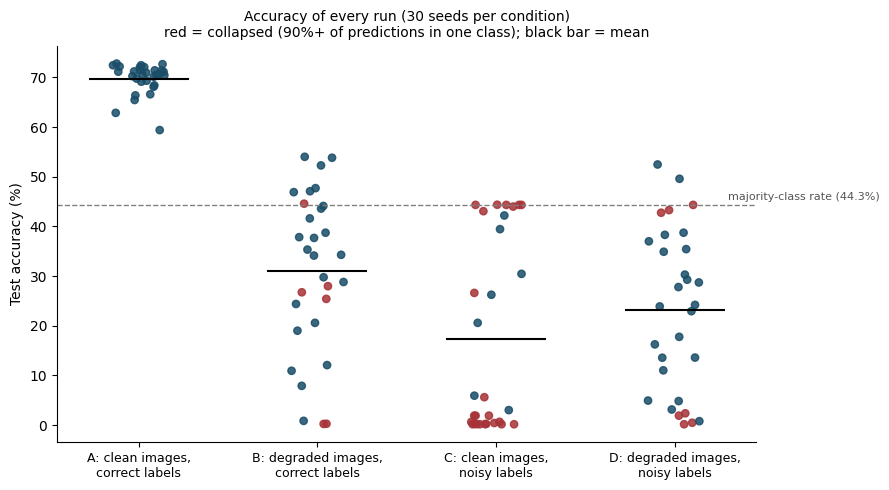

In [28]:
# Every run's accuracy as a dot, collapsed runs in red, so a few extreme runs cannot hide inside a mean
majority_rate = (test_df["label"] == test_df["label"].value_counts().idxmax()).mean()
short = ["A: clean images,\ncorrect labels", "B: degraded images,\ncorrect labels",
         "C: clean images,\nnoisy labels", "D: degraded images,\nnoisy labels"]
rng_jit = np.random.RandomState(0)
fig, ax = plt.subplots(figsize=(9, 5))
for i, c in enumerate(CONDITIONS):
    sub = results_df[results_df["condition"] == c["name"]]
    xj = i + rng_jit.uniform(-0.15, 0.15, len(sub))
    ax.scatter(xj, sub["accuracy"] * 100, s=28, alpha=0.85,
               c=np.where(sub["collapsed"], "#a63337", "#194d68"))
    ax.hlines(sub["accuracy"].mean() * 100, i - 0.28, i + 0.28, color="black", linewidth=1.5)
ax.axhline(majority_rate * 100, color="gray", linestyle="--", linewidth=1)
ax.text(3.3, majority_rate * 100 + 1, f"majority-class rate ({majority_rate*100:.1f}%)", fontsize=8, color="#555555")
ax.set_xticks(range(len(CONDITIONS))); ax.set_xticklabels(short, fontsize=9)
ax.set_ylabel("Test accuracy (%)")
ax.set_title(f"Accuracy of every run ({len(CONFIG['seeds'])} seeds per condition)\n"
             "red = collapsed (90%+ of predictions in one class); black bar = mean", fontsize=10)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("figure_every_run.png", dpi=300); plt.show()

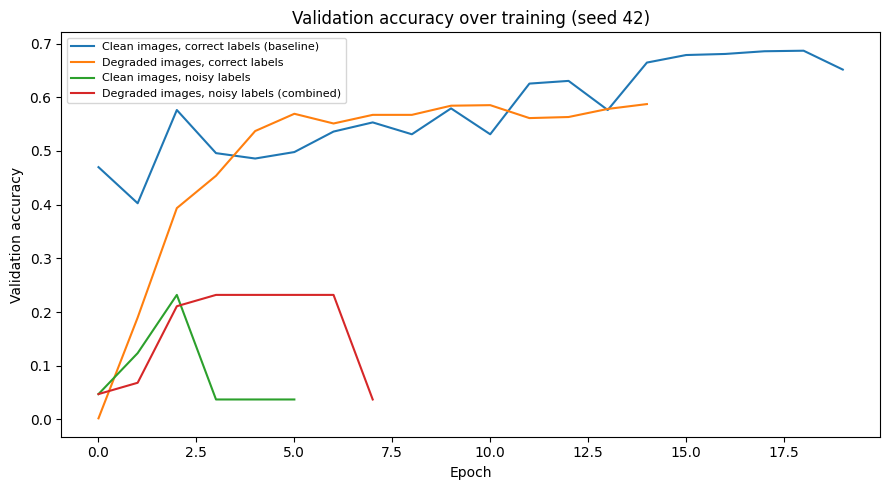

In [29]:
# Validation accuracy over training, one line per condition, for the first seed
plt.figure(figsize=(9, 5))
for condition in CONDITIONS:
    h = histories[f"{condition['key']}__seed{first_seed}"]
    plt.plot(h["val_accuracy"], label=condition["name"])
plt.xlabel("Epoch"); plt.ylabel("Validation accuracy")
plt.legend(fontsize=8)
plt.title(f"Validation accuracy over training (seed {first_seed})")
plt.tight_layout()
plt.show()


## 15. Paper Figures 1 and 3

Figure 1 (bar chart with baselines), the confusion matrices used as Figure 3, and the degradation steps. The runs shown in the confusion matrices are picked by a rule written in the code, not by hand.

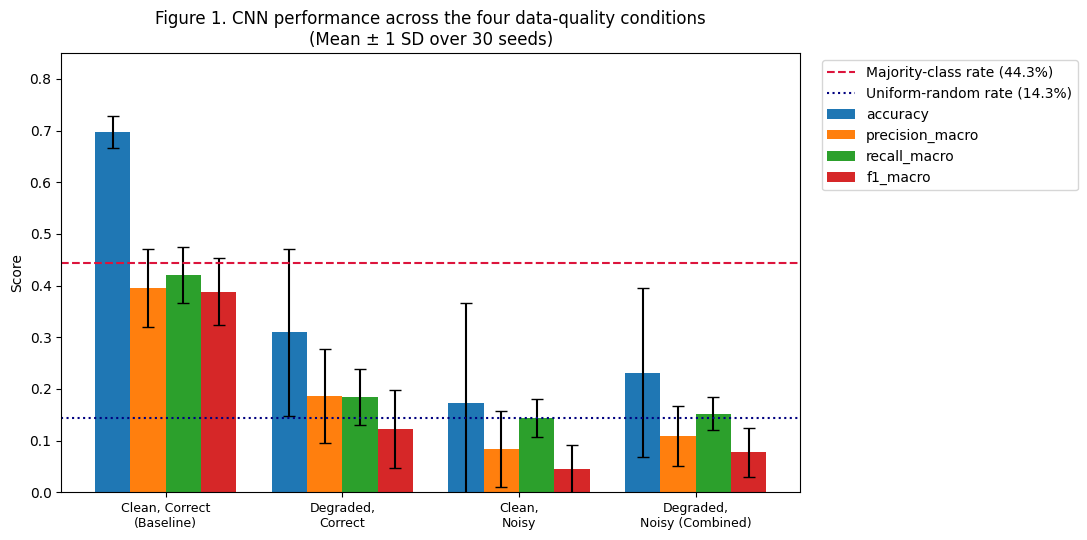

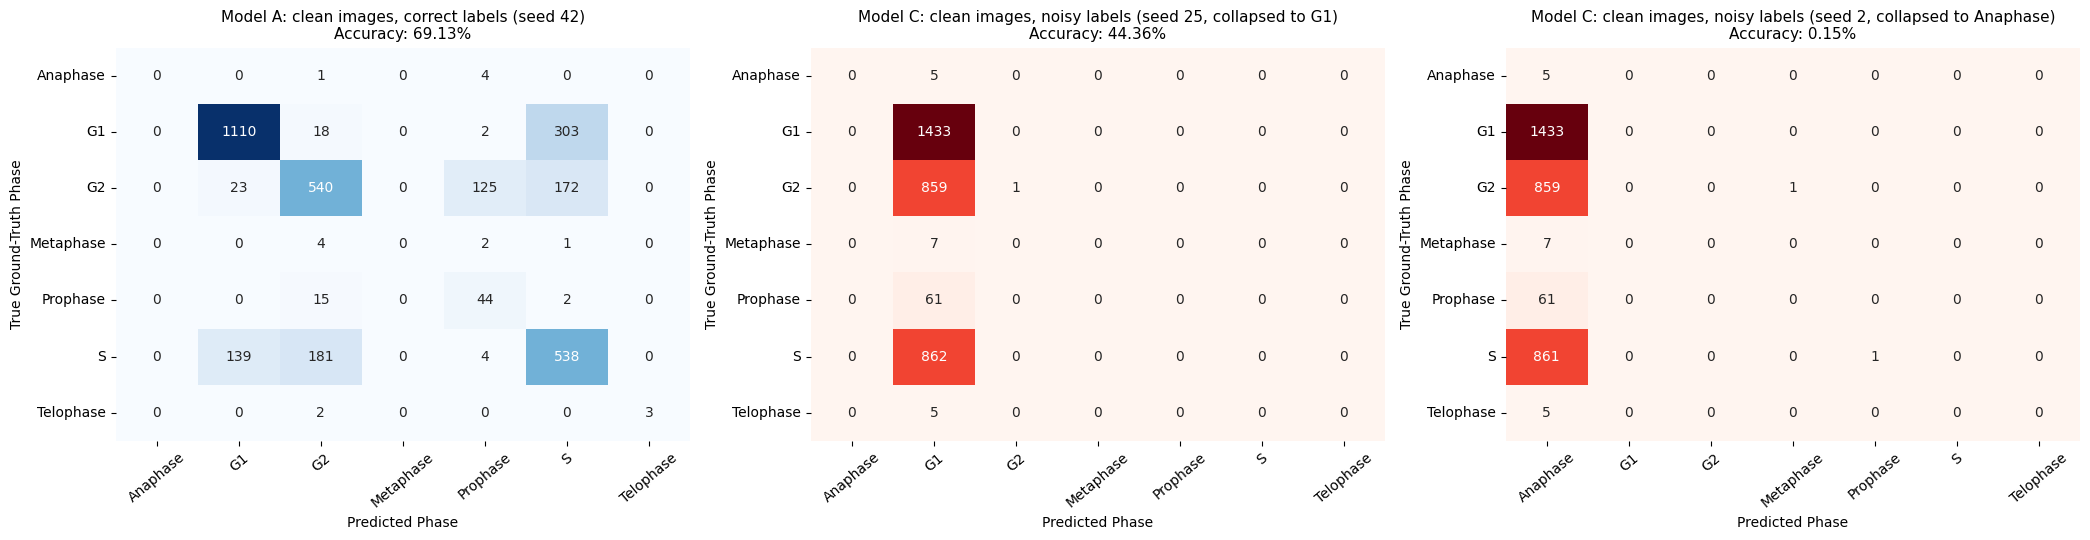

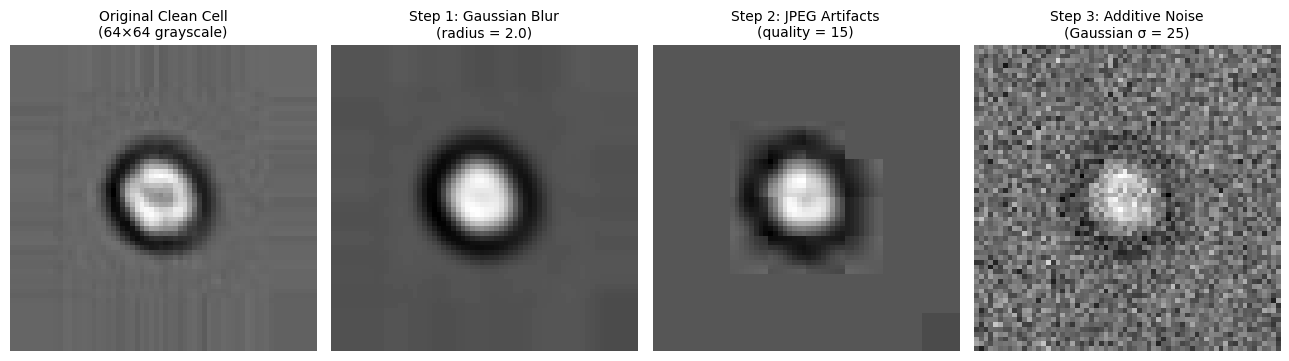

In [30]:
import io
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFilter
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# 1. UPDATE FIGURE 1: Bar chart with Majority-class and Uniform-random baselines
# ==============================================================================
metrics_to_plot = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
condition_names = [c["name"] for c in CONDITIONS]
x = np.arange(len(condition_names))
width = 0.2

plt.figure(figsize=(11, 5.5))
for i, m in enumerate(metrics_to_plot):
  means = [summary_df.loc[name, (m, "mean")] for name in condition_names]
  stds = [summary_df.loc[name, (m, "std")] for name in condition_names]
  plt.bar(x + i * width, means, width, yerr=stds, capsize=4, label=m)

# Reference lines from Figure 1 caption:
# Dashed line: majority-class rate in the test set, computed from test_df
majority_rate = (test_df["label"] == test_df["label"].value_counts().idxmax()).mean()
plt.axhline(
    y=majority_rate,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Majority-class rate ({majority_rate*100:.1f}%)",
)
# Dotted line: uniform random guessing for 7 classes (1/7 ≈ 14.3%)
plt.axhline(
    y=1 / 7,
    color="navy",
    linestyle=":",
    linewidth=1.5,
    label="Uniform-random rate (14.3%)",
)

plt.xticks(
    x + width * 1.5,
    [
        "Clean, Correct\n(Baseline)",
        "Degraded,\nCorrect",
        "Clean,\nNoisy",
        "Degraded,\nNoisy (Combined)",
    ],
    fontsize=9,
)
plt.ylabel("Score")
plt.ylim(0, 0.85)
plt.title(
    "Figure 1. CNN performance across the four data-quality conditions\n(Mean ±"
    f" 1 SD over {len(CONFIG['seeds'])} seeds)"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.savefig("figure1_performance_with_baselines.png", dpi=300)
plt.show()

# ==============================================================================
# 2. Confusion matrices: Model A (first seed) and two Model C runs chosen by rule
#    Middle panel: the collapsed Model C run with the HIGHEST accuracy (accuracy hides the collapse)
#    Right panel:  the Model C run with the LOWEST accuracy
#    If no Model C run collapsed, the middle panel shows the highest-accuracy Model C run.
# ==============================================================================
res_A = next(r for r in all_run_results if r["condition_key"] == "clean_correct" and r["seed"] == first_seed)
c_runs = [r for r in all_run_results if r["condition_key"] == "clean_noisy"]
c_collapsed = [r for r in c_runs if dominant_prediction(r["preds"])[1] >= COLLAPSE_SHARE]
res_C_mid = max(c_collapsed or c_runs, key=lambda r: r["accuracy"])
res_C_low = min(c_runs, key=lambda r: r["accuracy"])
panels = [(res_A, "Blues", "Model A: clean images, correct labels")]
panels.append((res_C_mid, "Reds", "Model C: clean images, noisy labels"))
if res_C_low is not res_C_mid:
    panels.append((res_C_low, "Reds", "Model C: clean images, noisy labels"))

classes = label_encoder.classes_
fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 5.5))
for ax, (r, cmap, name) in zip(axes, panels):
    cm = confusion_matrix(y_test_idx, r["preds"], labels=range(NUM_CLASSES))
    dom_cls, dom_share = dominant_prediction(r["preds"])
    flag = f", collapsed to {dom_cls}" if dom_share >= COLLAPSE_SHARE else ""
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=classes, yticklabels=classes, ax=ax, cbar=False)
    ax.set_title(f"{name} (seed {r['seed']}{flag})\nAccuracy: {r['accuracy']*100:.2f}%", fontsize=11)
    ax.set_xlabel("Predicted Phase"); ax.set_ylabel("True Ground-Truth Phase")
    ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.savefig("figure_confusion_matrix_collapse.png", dpi=300)
plt.show()

# ==============================================================================
# 3. ACTION ITEM (2): Example cell image at each degradation step
# ==============================================================================
# Pick one representative Jurkat cell image from the test set
sample_path = test_df.iloc[0]["filepath"]
orig_arr = load_image(sample_path, CONFIG["img_size"])

# Step 1: Gaussian Blur
img_pil = Image.fromarray(orig_arr)
blur_pil = img_pil.filter(ImageFilter.GaussianBlur(radius=CONFIG["blur_radius"]))
arr_blur = np.array(blur_pil, dtype=np.uint8)

# Step 2: JPEG compression artifacts
buf = io.BytesIO()
blur_pil.save(buf, format="JPEG", quality=CONFIG["jpeg_quality"])
buf.seek(0)
arr_jpeg = np.array(Image.open(buf).convert("L"), dtype=np.float32)

# Step 3: Additive Gaussian Noise (Full composite degradation)
np.random.seed(42)
noise = np.random.normal(0, CONFIG["noise_std"], arr_jpeg.shape)
arr_final = np.clip(arr_jpeg + noise, 0, 255).astype(np.uint8)

steps = [
    (orig_arr, "Original Clean Cell\n(64×64 grayscale)"),
    (arr_blur, f"Step 1: Gaussian Blur\n(radius = {CONFIG['blur_radius']})"),
    (
        arr_jpeg.astype(np.uint8),
        f"Step 2: JPEG Artifacts\n(quality = {CONFIG['jpeg_quality']})",
    ),
    (
        arr_final,
        f"Step 3: Additive Noise\n(Gaussian σ = {CONFIG['noise_std']})",
    ),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, (img_data, title) in zip(axes, steps):
  ax.imshow(img_data, cmap="gray")
  ax.set_title(title, fontsize=10)
  ax.axis("off")

plt.tight_layout()
plt.savefig("figure_degradation_steps.png", dpi=300)
plt.show()

## 16. Paper Figure 2

Redraws the bar chart used as Figure 2 in the paper, in the paper's styling, directly from `summary_df` (Section 13). No values are typed in. Figures 1 and 3 in the paper come from Section 15.


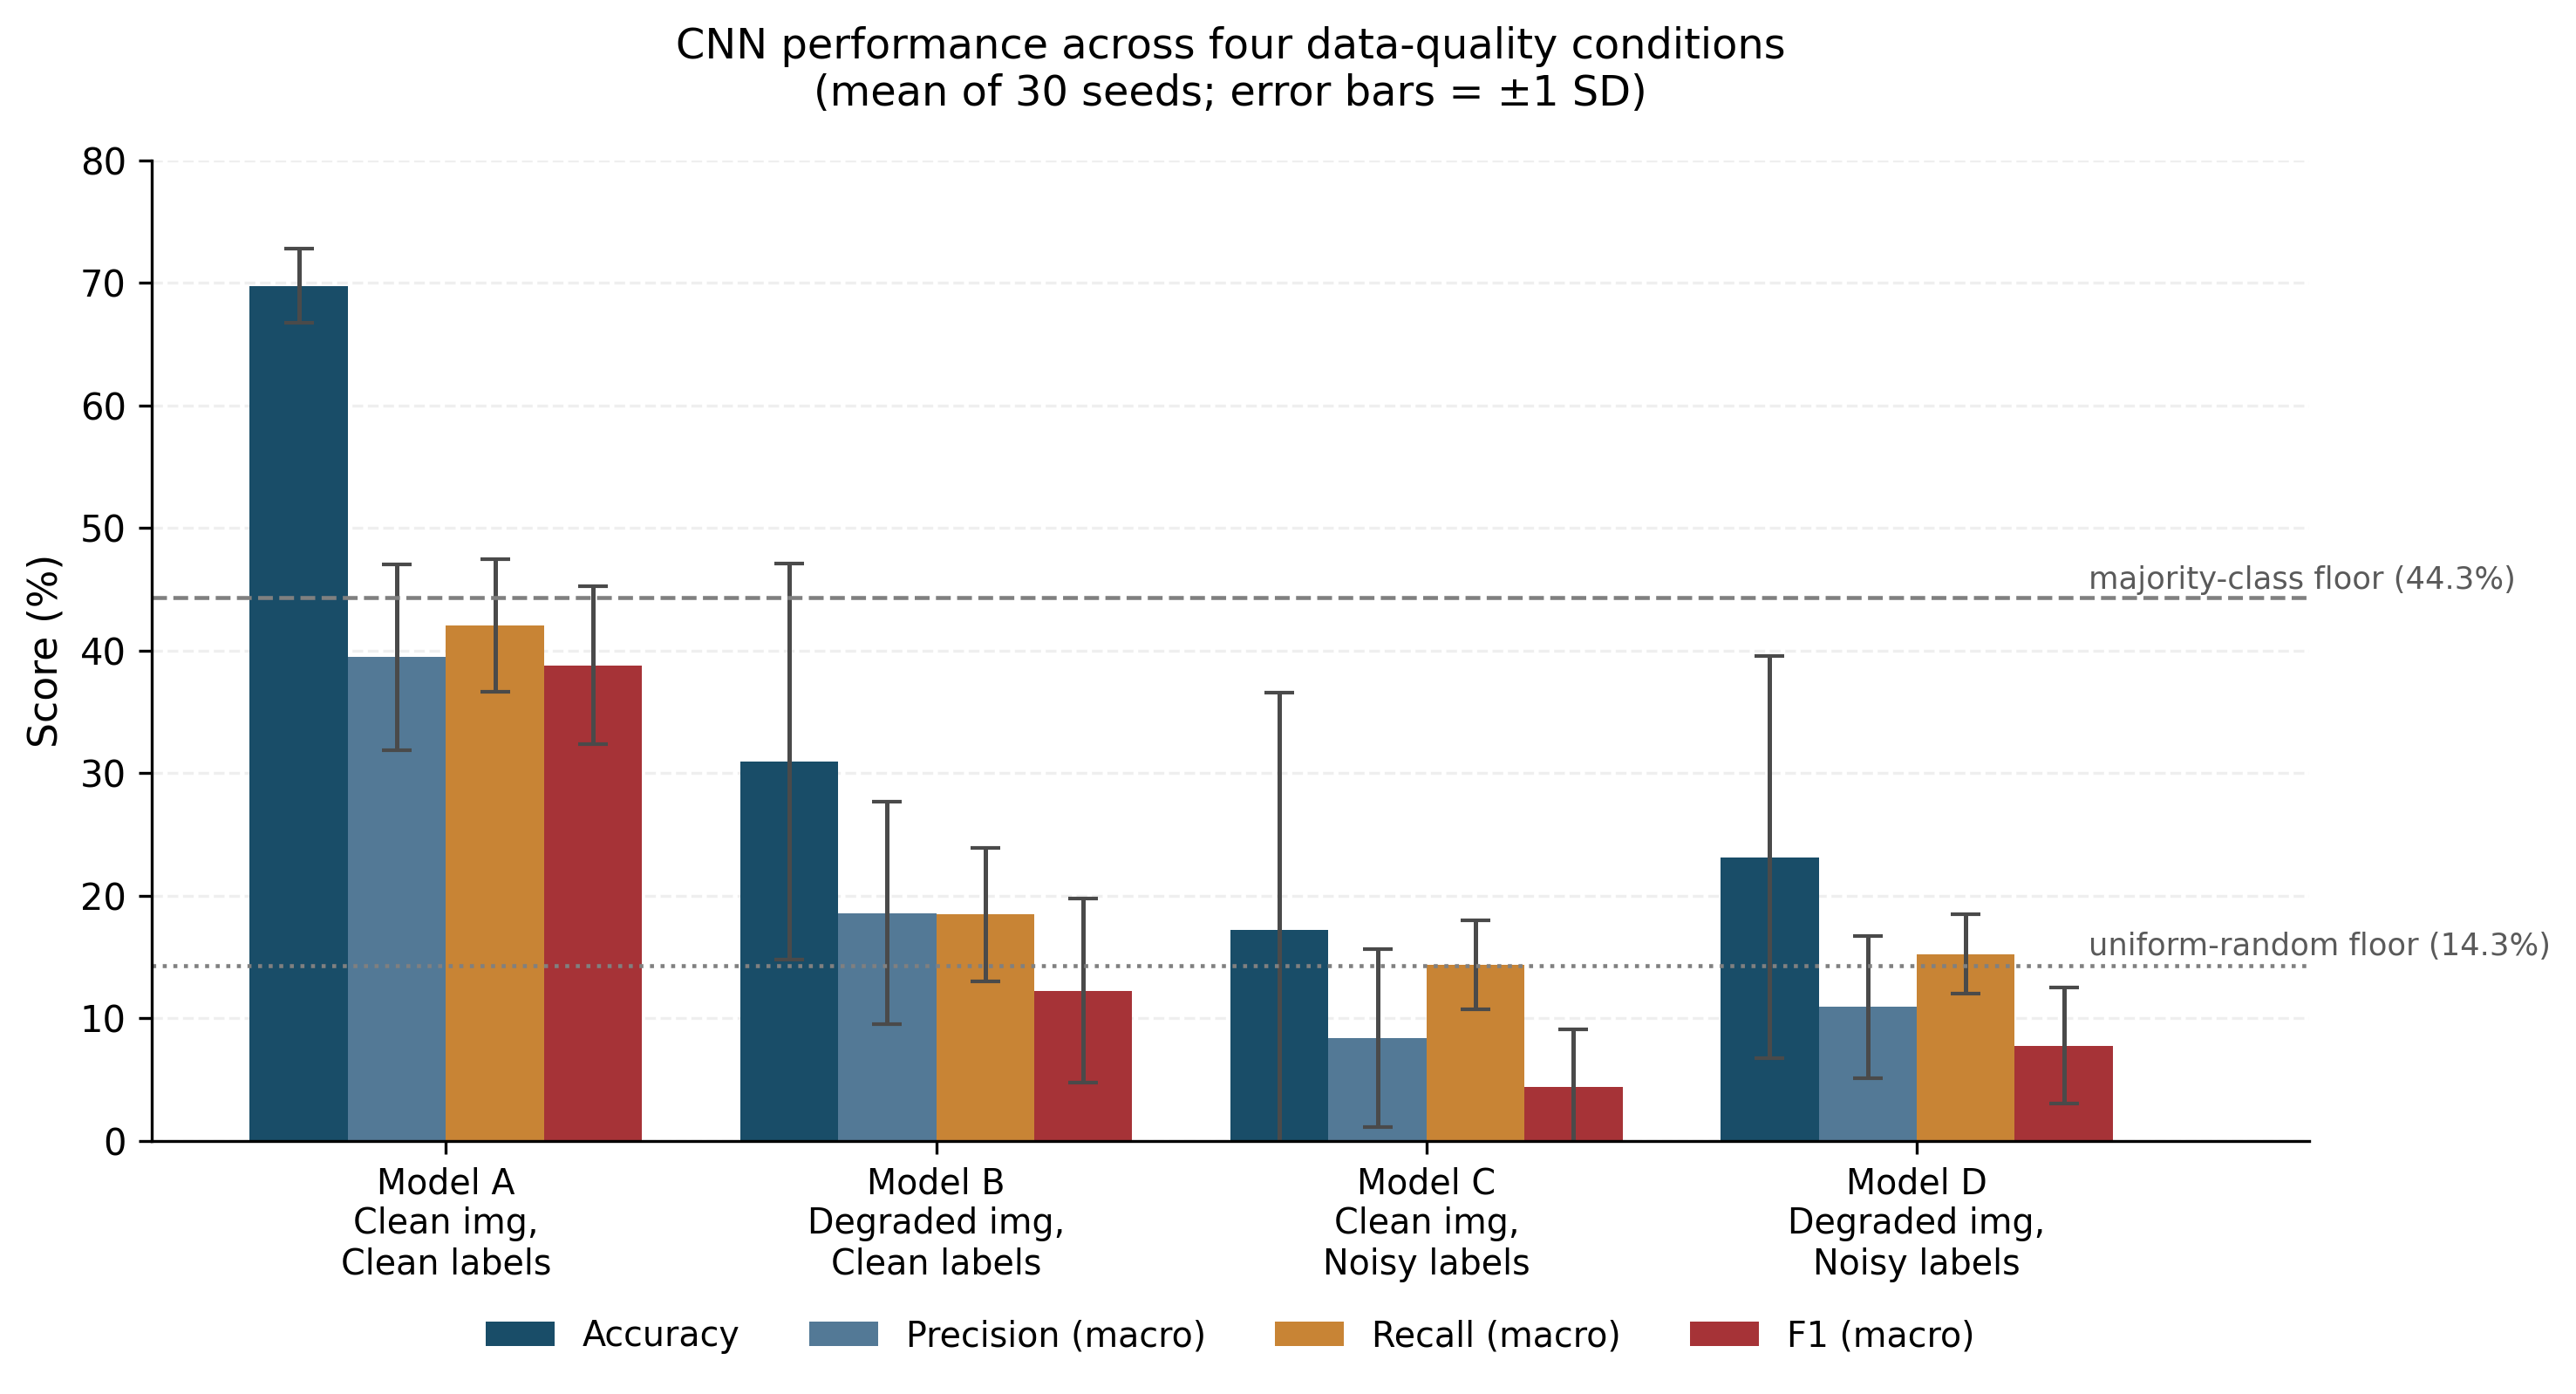

In [31]:
# Paper Figure 2: mean ± SD across seeds, drawn from summary_df computed in Section 13
metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
labels = ["Accuracy", "Precision (macro)", "Recall (macro)", "F1 (macro)"]
colors = ["#194d68", "#537996", "#c88435", "#a63337"]
names = [c["name"] for c in CONDITIONS]
xt = ["Model A\nClean img,\nClean labels", "Model B\nDegraded img,\nClean labels",
      "Model C\nClean img,\nNoisy labels", "Model D\nDegraded img,\nNoisy labels"]
x = np.arange(len(names)); width = 0.20
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=300)
for i, (m, lab) in enumerate(zip(metrics, labels)):
    means = [summary_df.loc[n, (m, "mean")] * 100 for n in names]
    stds = [summary_df.loc[n, (m, "std")] * 100 for n in names]
    ax.bar(x + (i - 1.5) * width, means, width, yerr=stds, label=lab, color=colors[i],
           capsize=4, error_kw={"elinewidth": 1.2, "ecolor": "#4a4a4a"})
majority = (test_df["label"] == "G1").mean() * 100
ax.axhline(y=majority, color="gray", linestyle="--", linewidth=1.1)
ax.text(3.35, majority + 0.7, f"majority-class floor ({majority:.1f}%)", color="#5a5a5a", fontsize=8.5)
ax.axhline(y=100 / 7, color="gray", linestyle=":", linewidth=1.1)
ax.text(3.35, 100 / 7 + 0.9, "uniform-random floor (14.3%)", color="#5a5a5a", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(xt, fontsize=9.5)
ax.set_ylabel("Score (%)", fontsize=11); ax.set_ylim(0, 80); ax.set_xlim(-0.6, 3.8)
ax.set_title(f"CNN performance across four data-quality conditions\n(mean of {len(CONFIG['seeds'])} seeds; error bars = ±1 SD)", fontsize=11.5, pad=15)
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="#cccccc"); ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=9.5)
plt.tight_layout(); plt.savefig("paper_figure2.png", dpi=300); plt.show()


## 17. Save results

Runs last, so every figure from Sections 14 to 16 is included. Saves per-run results (with the collapse
columns from Section 13b), the summary and collapse tables, one classification report per condition
(first seed), the first-seed models, every figure, and the GPU and seed record. Everything is zipped and
also copied to `MyDrive/jurkat_runs/results`.

In [32]:
OUT_DIR = "/content/results"
os.makedirs(OUT_DIR, exist_ok=True)

results_df.to_csv(os.path.join(OUT_DIR, "all_runs.csv"), index=False)
collapse_summary.to_csv(os.path.join(OUT_DIR, "collapse_summary.csv"), index=False)
json.dump({"gpu": GPU_NAME, "tensorflow": tf.__version__, "seeds": CONFIG["seeds"]}, open(os.path.join(OUT_DIR, "run_info.json"), "w"))
summary_df.to_csv(os.path.join(OUT_DIR, "summary_by_condition.csv"))

def save_classification_report(y_true, preds, class_names, path):
    present_labels = sorted(set(y_true.tolist()) | set(preds.tolist()))
    present_names = [class_names[i] for i in present_labels]
    report = classification_report(y_true, preds, labels=present_labels,
                                    target_names=present_names,
                                    zero_division=0, output_dict=True)
    pd.DataFrame(report).to_csv(path)

for condition in CONDITIONS:
    r = next(x for x in all_run_results if x["condition_key"] == condition["key"] and x["seed"] == first_seed)
    save_classification_report(
        y_test_idx, r["preds"], label_encoder.classes_,
        os.path.join(OUT_DIR, f"classification_report_{condition['key']}_seed{first_seed}.csv")
    )
    src_model = os.path.join(SAVE_DIR, f"model_{condition['key']}__seed{first_seed}.keras")
    if os.path.exists(src_model):
        shutil.copy(src_model, os.path.join(OUT_DIR, f"model_{condition['key']}_seed{first_seed}.keras"))

print("Saved to", OUT_DIR)
print(os.listdir(OUT_DIR))

# Optional: zip everything for download
for f in glob.glob("*.png"):
    shutil.copy(f, OUT_DIR)          # paper figures from Sections 14 to 16
!zip -r -q /content/results.zip {OUT_DIR}
shutil.copytree(OUT_DIR, os.path.join(SAVE_DIR, "results"), dirs_exist_ok=True)
shutil.copy("/content/results.zip", SAVE_DIR)
print("\nCopied to Google Drive:", os.path.join(SAVE_DIR, "results"))
print("Download with: from google.colab import files; files.download('/content/results.zip')")


Saved to /content/results
['model_clean_correct_seed42.keras', 'classification_report_degraded_noisy_seed42.csv', 'all_runs.csv', 'summary_by_condition.csv', 'collapse_summary.csv', 'model_degraded_correct_seed42.keras', 'model_clean_noisy_seed42.keras', 'run_info.json', 'classification_report_clean_noisy_seed42.csv', 'classification_report_degraded_correct_seed42.csv', 'model_degraded_noisy_seed42.keras', 'classification_report_clean_correct_seed42.csv']

Copied to Google Drive: /content/drive/MyDrive/jurkat_runs/results
Download with: from google.colab import files; files.download('/content/results.zip')
